# PCA — PyTorch (GPU-Accelerated)

## Model: Principal Component Analysis (Dimensionality Reduction)
- **Dataset**: Fashion-MNIST — 60,000 train / 10,000 test, 784 features (28×28 flattened), 10 classes
- **Task**: Compress 784 features while retaining maximum variance
- **Framework showcase**: GPU vs CPU eigendecomposition — `torch.linalg.eigh` on CUDA vs CPU

## GPU Acceleration Strategy
- Covariance matrix `X^T @ X` computed on GPU via `torch.matmul` (60K×784 → 784×784)
- Eigendecomposition via `torch.linalg.eigh` on GPU (CUDA LAPACK)
- Transform/inverse_transform: GPU matmul for projection and reconstruction
- float32 on GPU for speed, results match float64 NF/SK at task-relevant precision

In [1]:
import numpy as np
import pickle
import sys
import os
import torch

sys.path.append('../..')

from sklearn.neighbors import KNeighborsClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_scree, plot_reconstruction_grid,
                                  plot_pca_components, plot_component_accuracy)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
N_COMPONENTS_LIST = [10, 25, 50, 100, 150, 200]
IMAGE_SHAPE = (28, 28)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


class PCAGpu:
    """
    PCA via eigendecomposition on GPU using PyTorch.

    Same algorithm as NF PCAFromScratch, but all heavy ops
    (covariance, eigendecomposition, projection) run on CUDA.
    float32 for GPU speed — eigenvalues/vectors are accurate
    enough for dimensionality reduction at this scale.

    Args:
        n_components: Number of principal components to keep.
        device: torch device ('cuda' or 'cpu')
    """

    def __init__(self, n_components=None, device=torch.device('cuda')):
        self.n_components = n_components
        self.device = device
        self.components_ = None        # (k, d) tensor — top k eigenvectors (rows)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None              # (d,) tensor
        self.n_components_ = None

    def fit(self, X):
        """
        Compute principal components on GPU.

        Args:
            X: (n, d) torch tensor on device
        Returns:
            self
        """
        n, d = X.shape

        # Step 1: Center
        self.mean_ = X.mean(dim=0)
        X_centered = X - self.mean_

        # Step 2: Covariance matrix — (d, d) on GPU
        # matmul on GPU: (784, 60K) @ (60K, 784) → (784, 784)
        cov = (X_centered.T @ X_centered) / n

        # Step 3: Eigendecomposition on GPU
        # torch.linalg.eigh returns ascending order (same as np.linalg.eigh)
        eigenvalues, eigenvectors = torch.linalg.eigh(cov)

        # Reverse to descending (largest variance first)
        idx = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Step 4: Keep top k
        k = self.n_components if self.n_components is not None else d
        self.n_components_ = k
        self.components_ = eigenvectors[:, :k].T  # (k, d)
        self.explained_variance_ = eigenvalues[:k]

        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = eigenvalues[:k] / total_var

        # Full spectrum for scree plots
        self._all_variance_ratio = (eigenvalues / total_var).cpu().numpy()

        return self

    def transform(self, X):
        """Project to reduced space on GPU."""
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, X_reduced):
        """Reconstruct from reduced representation on GPU."""
        return X_reduced @ self.components_ + self.mean_


# Step 1: Load preprocessed Fashion-MNIST
X_train_np, X_test_np, y_train, y_test, meta = load_processed_data('pca')

# Load scaler for reconstruction visualizations
with open('../../data/processed/pca/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Convert to GPU tensors (float32)
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)

print("=" * 60)
print(f"PCA Pipeline — {FRAMEWORK}")
print("=" * 60)
print(f"[1/8] Data loaded + PCAGpu defined")
print(f"  Train: {tuple(X_train.shape)}, Test: {tuple(X_test.shape)}")
print(f"  Device: {device}, Dtype: {X_train.dtype}")
print(f"  Classes: {meta['n_classes']} — {', '.join(meta['class_names'])}")
print(f"  Scaler: mean shape={scaler['mean'].shape}, std shape={scaler['std'].shape}")
print(f"  GPU memory used: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.8 GB
PCA Pipeline — PyTorch
[1/8] Data loaded + PCAGpu defined
  Train: (60000, 784), Test: (10000, 784)
  Device: cuda, Dtype: torch.float32
  Classes: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
  Scaler: mean shape=(784,), std shape=(784,)
  GPU memory used: 220.2 MB


[2/8] Full PCA fitted (GPU eigendecomposition)
  Components: 784
  Top 10 explain: 62.2%
  90% variance at: 137 components
  95% variance at: 256 components


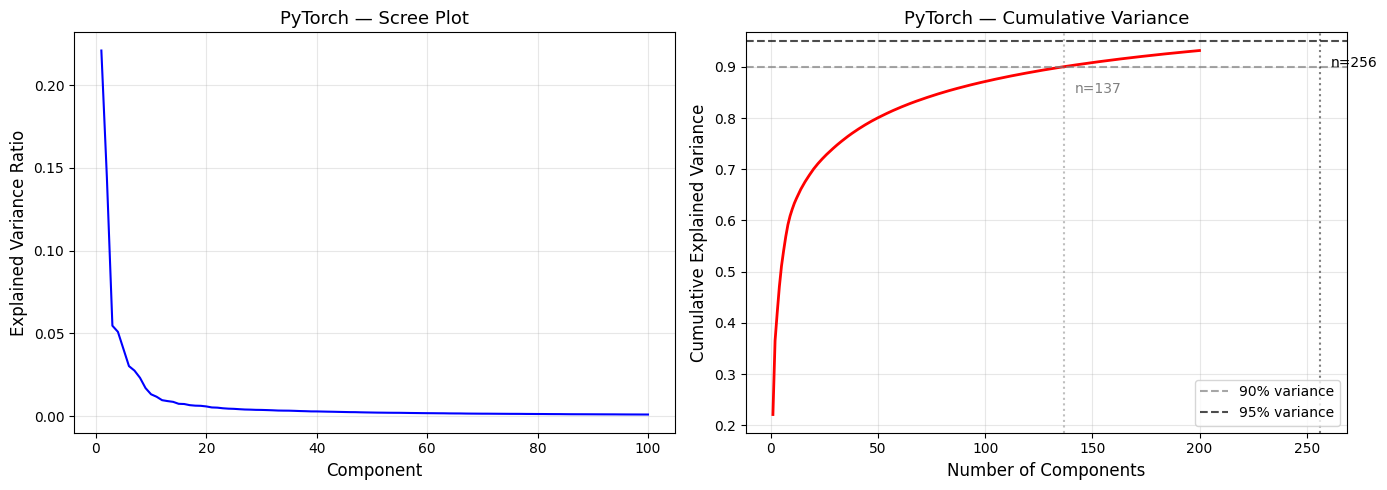

In [2]:
# Step 2: Fit full PCA + scree plot

# Fit with all components to get full eigenvalue spectrum on GPU
pca_full = PCAGpu(n_components=None, device=device)
pca_full.fit(X_train)

print("=" * 60)
print("[2/8] Full PCA fitted (GPU eigendecomposition)")
print("=" * 60)
print(f"  Components: {pca_full.n_components_}")
print(f"  Top 10 explain: {sum(pca_full._all_variance_ratio[:10]):.1%}")
print(f"  90% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.90) + 1} components")
print(f"  95% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.95) + 1} components")

# Scree plot — _all_variance_ratio is already numpy from fit()
plot_scree(pca_full._all_variance_ratio, FRAMEWORK,
           save_path=f'{RESULTS_DIR}/scree_plot.png')

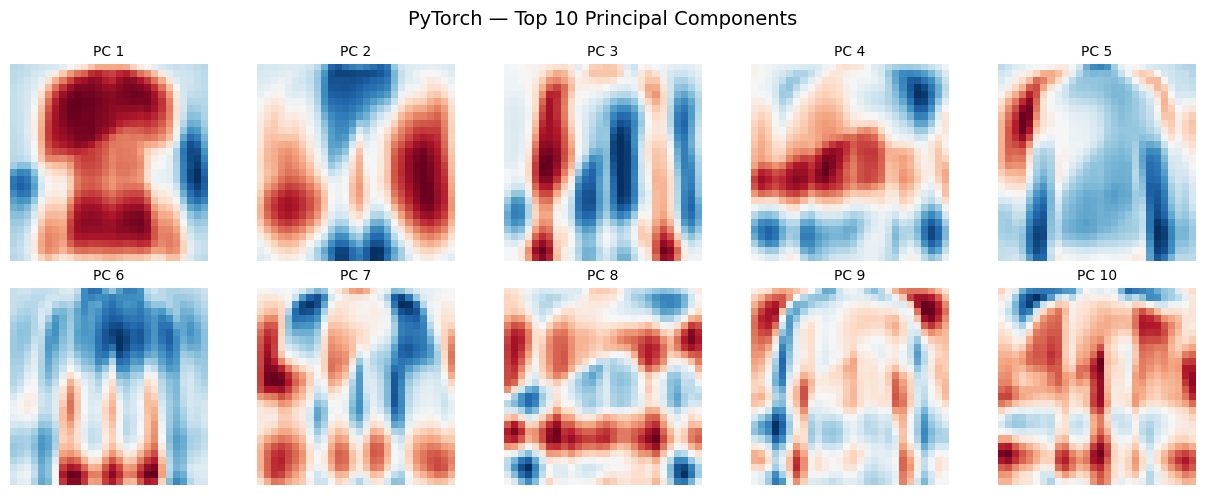

[3/8] Principal components visualized
  PC1 explains: 22.1%
  PC2 explains: 14.4%
  PC10 explains: 1.3%


In [3]:
# Step 3: Visualize top principal components as images

# components_ is a GPU tensor — convert to numpy for visualization
plot_pca_components(pca_full.components_.cpu().numpy(), IMAGE_SHAPE, n_components=10,
                    framework=FRAMEWORK, save_path=f'{RESULTS_DIR}/principal_components.png')

ev_ratio = pca_full.explained_variance_ratio_.cpu().numpy()
print("=" * 60)
print("[3/8] Principal components visualized")
print("=" * 60)
print(f"  PC1 explains: {ev_ratio[0]:.1%}")
print(f"  PC2 explains: {ev_ratio[1]:.1%}")
print(f"  PC10 explains: {ev_ratio[9]:.1%}")

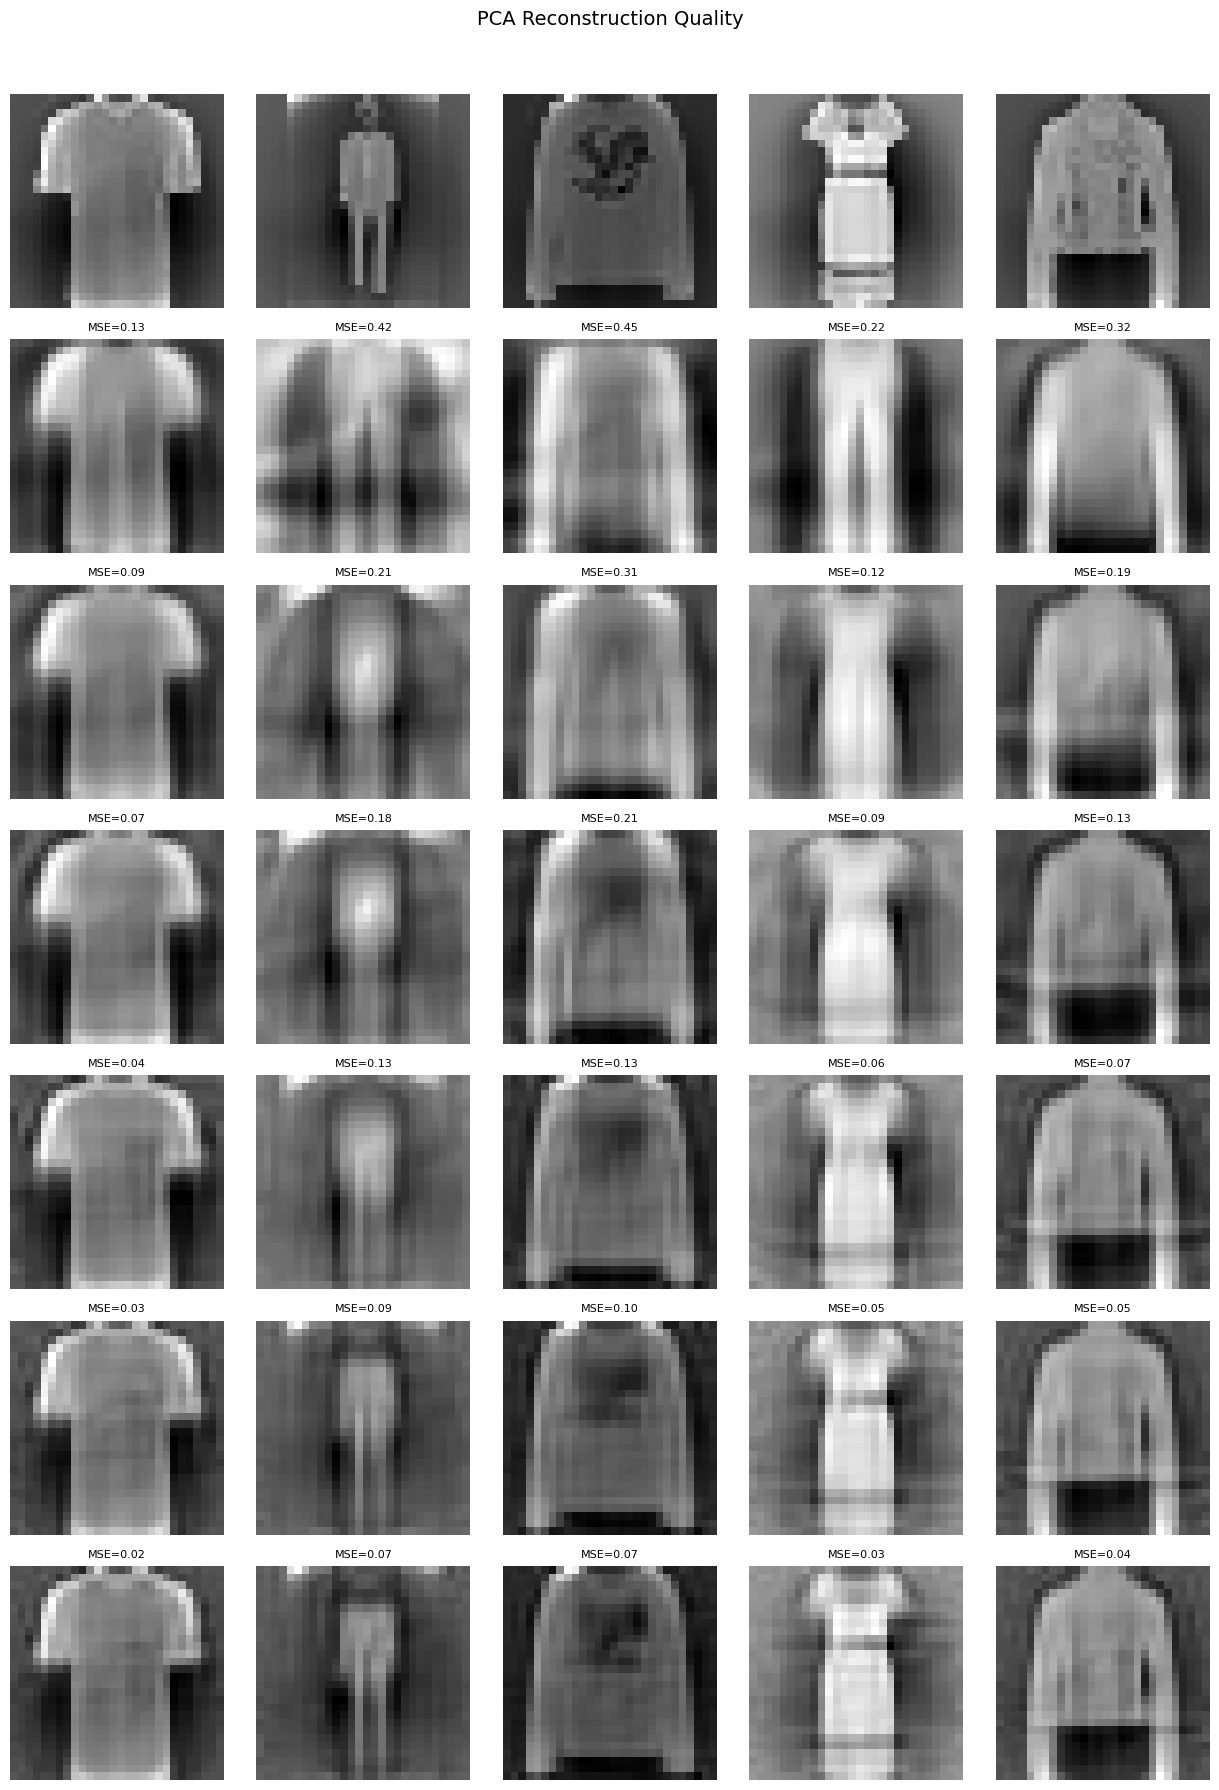

[4/8] Reconstruction quality
  n= 10: MSE=0.3077
  n= 25: MSE=0.1846
  n= 50: MSE=0.1361
  n=100: MSE=0.0886
  n=150: MSE=0.0623
  n=200: MSE=0.0462


In [4]:
# Step 4: Reconstruction at different component counts

from collections import OrderedDict

# Pick 5 diverse test samples (same seed = same indices as SK/NF)
np.random.seed(RANDOM_STATE)
sample_indices = []
for cls in range(5):
    cls_idx = np.where(y_test == cls)[0]
    sample_indices.append(np.random.choice(cls_idx))
originals_gpu = X_test[sample_indices]

# Reconstruct at each component count on GPU, convert to numpy for plotting
reconstructions = OrderedDict()
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCAGpu(n_components=n_comp, device=device)
    pca_n.fit(X_train)
    X_reduced = pca_n.transform(originals_gpu)
    X_recon = pca_n.inverse_transform(X_reduced)
    reconstructions[n_comp] = X_recon.cpu().numpy()

originals_np = originals_gpu.cpu().numpy()
plot_reconstruction_grid(originals_np, reconstructions, IMAGE_SHAPE, n_samples=5,
                         save_path=f'{RESULTS_DIR}/reconstruction_grid.png')

print("=" * 60)
print("[4/8] Reconstruction quality")
print("=" * 60)
for n_comp, recon in reconstructions.items():
    mse = np.mean((originals_np - recon) ** 2)
    print(f"  n={n_comp:>3}: MSE={mse:.4f}")

[5/8] Component sweep — KNN accuracy at each n_components
  n= 10: accuracy=0.8014  (784 → 10, 1.3%)
  n= 25: accuracy=0.8385  (784 → 25, 3.2%)
  n= 50: accuracy=0.8506  (784 → 50, 6.4%)
  n=100: accuracy=0.8575  (784 → 100, 12.8%)
  n=150: accuracy=0.8599  (784 → 150, 19.1%)
  n=200: accuracy=0.8597  (784 → 200, 25.5%)


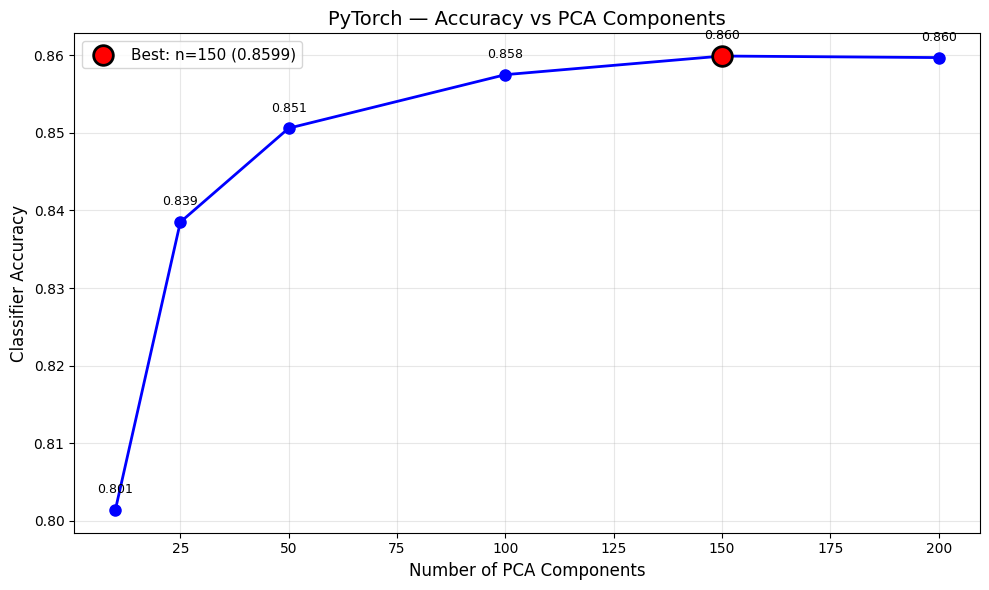

In [5]:
# Step 5: Downstream classifier accuracy vs components

# KNN runs on CPU (sklearn) — transform on GPU, then .cpu().numpy() for KNN
print("=" * 60)
print("[5/8] Component sweep — KNN accuracy at each n_components")
print("=" * 60)

accuracies = []
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCAGpu(n_components=n_comp, device=device)
    pca_n.fit(X_train)
    X_train_pca = pca_n.transform(X_train).cpu().numpy()
    X_test_pca = pca_n.transform(X_test).cpu().numpy()

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    accuracies.append(acc)
    print(f"  n={n_comp:>3}: accuracy={acc:.4f}  (784 → {n_comp}, {n_comp/784*100:.1f}%)")

plot_component_accuracy(N_COMPONENTS_LIST, accuracies, FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/component_accuracy.png')